In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from typing import Tuple

from deltafq.strategy.base import BaseStrategy


In [2]:
# 1. 读取基金数据，并重命名列名，以适应dfq回测等
data = pd.read_csv("160119.csv", index_col='净值日期')
data.index = pd.to_datetime(data.index)
data = data.rename(columns={'单位净值': 'close'})
data.index.name = 'date'

# 定义回测日期
start_date = '2021-01-01'
end_date = '2025-12-25'
data = data[start_date:end_date]

data


,close,累计净值,日增长率,申购状态,赎回状态,分红送配
date,,,,,,
2021-01-04,1.6907,1.7907,1.74%,开放申购,开放赎回,NaN
2021-01-05,1.7046,1.8046,0.82%,开放申购,开放赎回,NaN
2021-01-06,1.7018,1.8018,-0.16%,开放申购,开放赎回,NaN
2021-01-07,1.7042,1.8042,0.14%,开放申购,开放赎回,NaN
2021-01-08,1.7096,1.8096,0.32%,开放申购,开放赎回,NaN
...,...,...,...,...,...,...
2025-12-19,2.0168,2.1168,0.94%,开放申购,开放赎回,NaN
2025-12-22,2.0399,2.1399,1.15%,开放申购,开放赎回,NaN
2025-12-23,2.0401,2.1401,0.01%,开放申购,开放赎回,NaN


In [3]:
# 2. 波动策略：当N日内最大跌幅达到阈值时，加仓固定金额
class VolatilityStrategy(BaseStrategy):
    """
    波动策略：当N日内最大跌幅达到阈值时加仓
    
    策略逻辑：
    - 计算过去N日内的最大跌幅
    - 当最大跌幅达到阈值时，触发买入信号
    - 每次加仓固定金额
    """
    
    def __init__(self, 
                 window: int = 10, 
                 threshold: float = 0.05,
                 name: str = "VolatilityStrategy"):
        """
        Args:
            window: 计算跌幅的时间窗口（天数），默认10日
            threshold: 跌幅阈值（如0.05表示5%），默认0.05
            name: 策略名称
        """
        super().__init__(name=name)
        self.window = window
        self.threshold = threshold
    
    def generate_signals(self, data: pd.DataFrame) -> pd.Series:
        """
        生成买入信号
        
        核心逻辑：
        1. 计算每日相对于过去N日最高价的跌幅
        2. 如果跌幅达到阈值，则生成买入信号
        """
        signals = pd.Series(0, index=data.index, dtype=int)
        
        # 计算过去N日内的最高价
        rolling_max = data['close'].rolling(window=self.window, min_periods=1).max()
        
        # 计算当前价格相对于过去N日最高价的跌幅
        drawdown = (data['close'] - rolling_max) / rolling_max
        
        # 当跌幅达到阈值时，生成买入信号（1表示买入）
        # 注意：drawdown是负数，所以判断条件是 <= -threshold
        signals[drawdown <= -self.threshold] = 1
        
        return signals

# 使用策略：10日内最大跌幅达到5%时加仓
strategy = VolatilityStrategy(window=10, threshold=0.05, name="VolatilityStrategy_10d_5pct")
result = strategy.run(data)
signals = result["signals"]

print(f"策略名称: {result['strategy_name']}")
print(f"窗口期: {strategy.window}日")
print(f"跌幅阈值: {strategy.threshold*100:.1f}%")
print(f"买入信号数: {(signals == 1).sum()}")
print(f"持有信号数: {(signals == 0).sum()}")


[20:47:35] VolatilityStrategy_10d_5pct >>> INFO     >>> Initializing strategy: VolatilityStrategy_10d_5pct
[20:47:35] VolatilityStrategy_10d_5pct >>> INFO     >>> Running strategy: VolatilityStrategy_10d_5pct
策略名称: VolatilityStrategy_10d_5pct
窗口期: 10日
跌幅阈值: 5.0%
买入信号数: 112
持有信号数: 1099


In [4]:
# 查看信号
signals


date
2021-01-04    0
2021-01-05    0
2021-01-06    0
2021-01-07    0
2021-01-08    0
             ..
2025-12-19    0
2025-12-22    0
2025-12-23    0
2025-12-24    0
2025-12-25    0
Length: 1211, dtype: int64

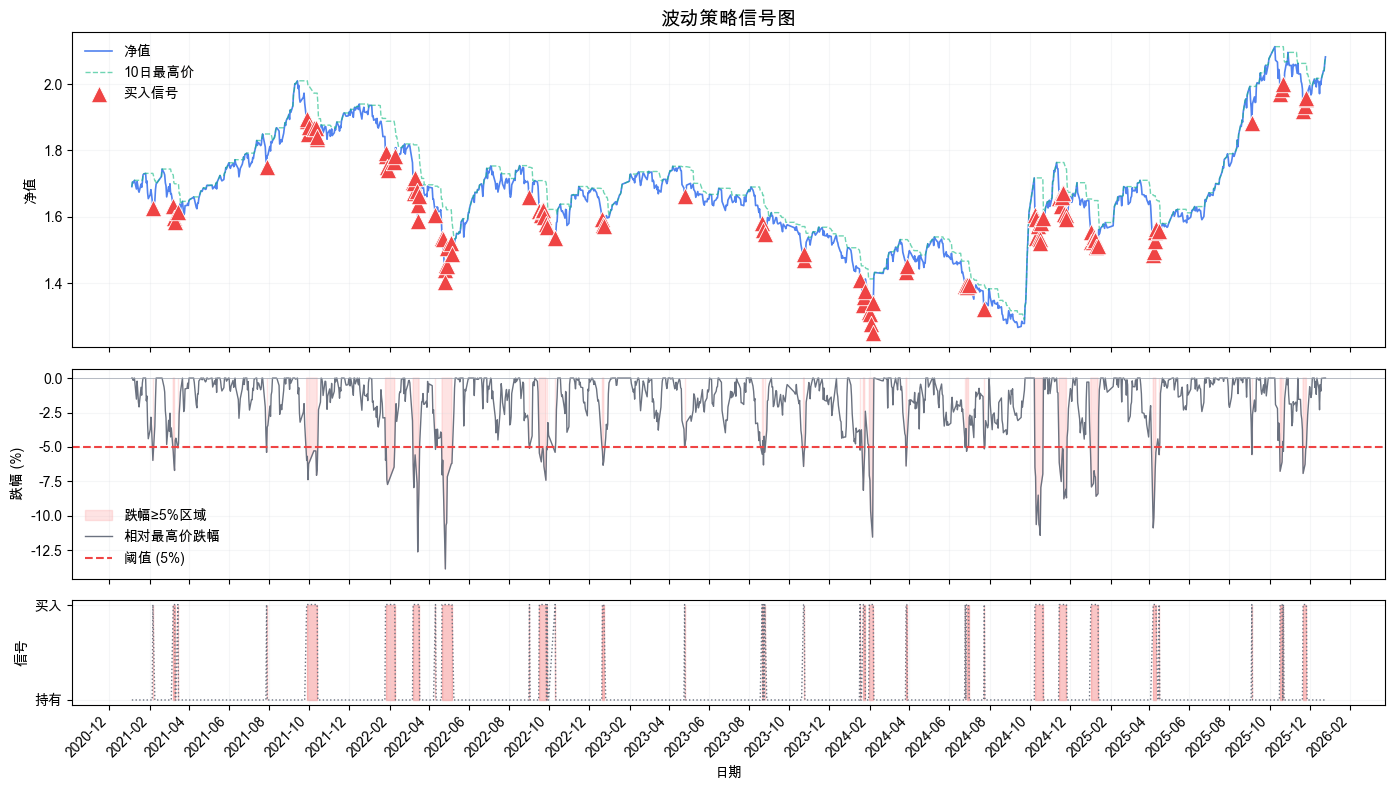

In [5]:
# 4. 可视化策略信号
def plot_volatility_signals(data: pd.DataFrame, signals: pd.Series, 
                            window: int = 10, threshold: float = 0.05,
                            title: str = "波动策略信号图") -> None:
    """可视化基金价格和买入信号，同时显示N日最高价和跌幅"""
    # 设置中文字体
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    
    fig, (ax_price, ax_drawdown, ax_signal) = plt.subplots(
        3, 1, figsize=(14, 8), sharex=True, 
        gridspec_kw={"height_ratios": [3, 2, 1]}
    )
    
    # 计算滚动最高价和跌幅
    rolling_max = data['close'].rolling(window=window, min_periods=1).max()
    drawdown = (data['close'] - rolling_max) / rolling_max * 100  # 转换为百分比
    
    # 价格图
    ax_price.plot(data.index, data['close'], color="#2563eb", linewidth=1.2, label="净值", alpha=0.8)
    ax_price.plot(data.index, rolling_max, color="#10b981", linewidth=1.0, 
                  linestyle="--", label=f"{window}日最高价", alpha=0.6)
    
    buy_mask = signals == 1
    ax_price.scatter(
        data.index[buy_mask],
        data['close'][buy_mask],
        marker="^",
        color="#ef4444",
        edgecolors="white",
        linewidths=0.6,
        s=140,
        label="买入信号",
        zorder=3
    )
    
    ax_price.set_title(title, fontsize=14, fontweight='bold')
    ax_price.set_ylabel("净值")
    ax_price.grid(True, alpha=0.2, color="#d1d5db")
    ax_price.legend(frameon=False, loc="upper left")
    
    # 跌幅图
    ax_drawdown.fill_between(data.index, drawdown, 0, 
                             where=(drawdown <= -threshold*100),
                             color="#fca5a5", alpha=0.3, label=f"跌幅≥{threshold*100:.0f}%区域")
    ax_drawdown.plot(data.index, drawdown, color="#6b7280", linewidth=1.0, label="相对最高价跌幅")
    ax_drawdown.axhline(y=-threshold*100, color="#ef4444", linestyle="--", 
                        linewidth=1.5, label=f"阈值 ({threshold*100:.0f}%)")
    ax_drawdown.axhline(y=0, color="#9ca3af", linestyle="-", linewidth=0.5)
    
    ax_drawdown.set_ylabel("跌幅 (%)")
    ax_drawdown.grid(True, alpha=0.2, color="#d1d5db")
    ax_drawdown.legend(frameon=False, loc="lower left")
    
    # 信号图
    ax_signal.plot(signals.index, signals.values, color="#6b7280", linewidth=1.0, linestyle=":")
    ax_signal.fill_between(signals.index, 0, signals.values, 
                           where=(signals == 1), color="#ef4444", alpha=0.3)
    ax_signal.set_ylabel("信号")
    ax_signal.set_xlabel("日期")
    ax_signal.set_yticks([0, 1])
    ax_signal.set_yticklabels(["持有", "买入"])
    ax_signal.grid(True, alpha=0.2, color="#d1d5db")
    
    # 日期格式
    for ax in (ax_price, ax_drawdown, ax_signal):
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()

plot_volatility_signals(data, signals, window=10, threshold=0.05)


In [6]:
# 5. 回测：当触发信号时加仓固定金额
from datetime import datetime

def backtest_volatility_strategy(data: pd.DataFrame, signals: pd.Series, 
                                 investment_amount: float = 2000, 
                                 commission: float = 0.001) -> Tuple[pd.DataFrame, dict]:
    """
    波动策略回测
    
    Args:
        data: 包含close列的数据
        signals: 买入信号序列（1=买入，0=持有）
        investment_amount: 每次加仓金额（默认2000元）
        commission: 手续费率（默认0.1%）
    
    Returns:
        values_df: 每日资产明细
        summary: 回测摘要
    """
    shares = 0
    total_invested = 0
    records = []
    
    for date, row in data.iterrows():
        price = row['close']
        signal = signals.loc[date] if date in signals.index else 0
        
        # 买入信号：加仓固定金额
        if signal == 1:
            # 投入固定金额，扣除手续费后用于买入
            net_amount = investment_amount * (1 - commission)  # 实际买入金额
            shares_bought = net_amount / price
            shares += shares_bought
            total_invested += investment_amount
        
        # 计算资产
        position_value = shares * price
        total_value = position_value
        
        records.append({
            'date': date,
            'price': price,
            'signal': signal,
            'shares': shares,
            'position_value': position_value,
            'total_value': total_value,
            'total_invested': total_invested
        })
    
    values_df = pd.DataFrame(records).set_index('date')
    
    # 计算摘要
    final_value = values_df['total_value'].iloc[-1]
    total_return = (final_value / total_invested - 1) * 100 if total_invested > 0 else 0
    buy_count = (signals == 1).sum()
    
    # 计算年化收益率
    start_date = values_df.index[0]
    end_date = values_df.index[-1]
    years = (end_date - start_date).days / 365.25
    annual_return = ((final_value / total_invested) ** (1 / years) - 1) * 100 if total_invested > 0 and years > 0 else 0
    
    summary = {
        '累计投入': f'{total_invested:,.2f}',
        '最终资产': f'{final_value:,.2f}',
        '累计收益': f'{final_value - total_invested:,.2f}',
        '累计收益率': f'{total_return:.2f}%',
        '年化收益率': f'{annual_return:.2f}%',
        '投资年限': f'{years:.2f}年',
        '加仓次数': buy_count,
        '每次加仓金额': f'{investment_amount:,.2f}',
        '持有份额': f'{shares:,.4f}',
        '最终净值': f'{values_df["price"].iloc[-1]:.4f}',
        '起始日期': start_date.strftime('%Y-%m-%d'),
        '结束日期': end_date.strftime('%Y-%m-%d')
    }
    
    return values_df, summary

def print_summary(summary: dict, title: str = "回测摘要"):
    """格式化打印回测摘要"""
    print("=" * 50)
    print(f"  {title}")
    print("=" * 50)
    for key, value in summary.items():
        print(f"  {key:12s}: {value}")
    print("=" * 50)

# 运行回测：每次加仓2000元
values_df, summary = backtest_volatility_strategy(data, signals, investment_amount=2000, commission=0)

# 格式化打印摘要
print_summary(summary)

# 查看最近10天资产
print("\n最近10天资产:")
print(values_df[['price', 'signal', 'shares', 'total_value', 'total_invested']].tail(10))


  回测摘要
  累计投入        : 224,000.00
  最终资产        : 293,920.65
  累计收益        : 69,920.65
  累计收益率       : 31.21%
  年化收益率       : 5.62%
  投资年限        : 4.97年
  加仓次数        : 112
  每次加仓金额      : 2,000.00
  持有份额        : 141,179.0444
  最终净值        : 2.0819
  起始日期        : 2021-01-04
  结束日期        : 2025-12-25

最近10天资产:
             price  signal         shares    total_value  total_invested
date                                                                    
2025-12-12  2.0172       0  141179.044352  284786.368266          224000
2025-12-15  2.0013       0  141179.044352  282541.621461          224000
2025-12-16  1.9708       0  141179.044352  278235.660608          224000
2025-12-17  2.0077       0  141179.044352  283445.167345          224000
2025-12-18  1.9981       0  141179.044352  282089.848519          224000
2025-12-19  2.0168       0  141179.044352  284729.896648          224000
2025-12-22  2.0399       0  141179.044352  287991.132573          224000
2025-12-23  2.0401       0  

[20:47:38] PerformanceChart     >>> INFO     >>> Initializing performance chart


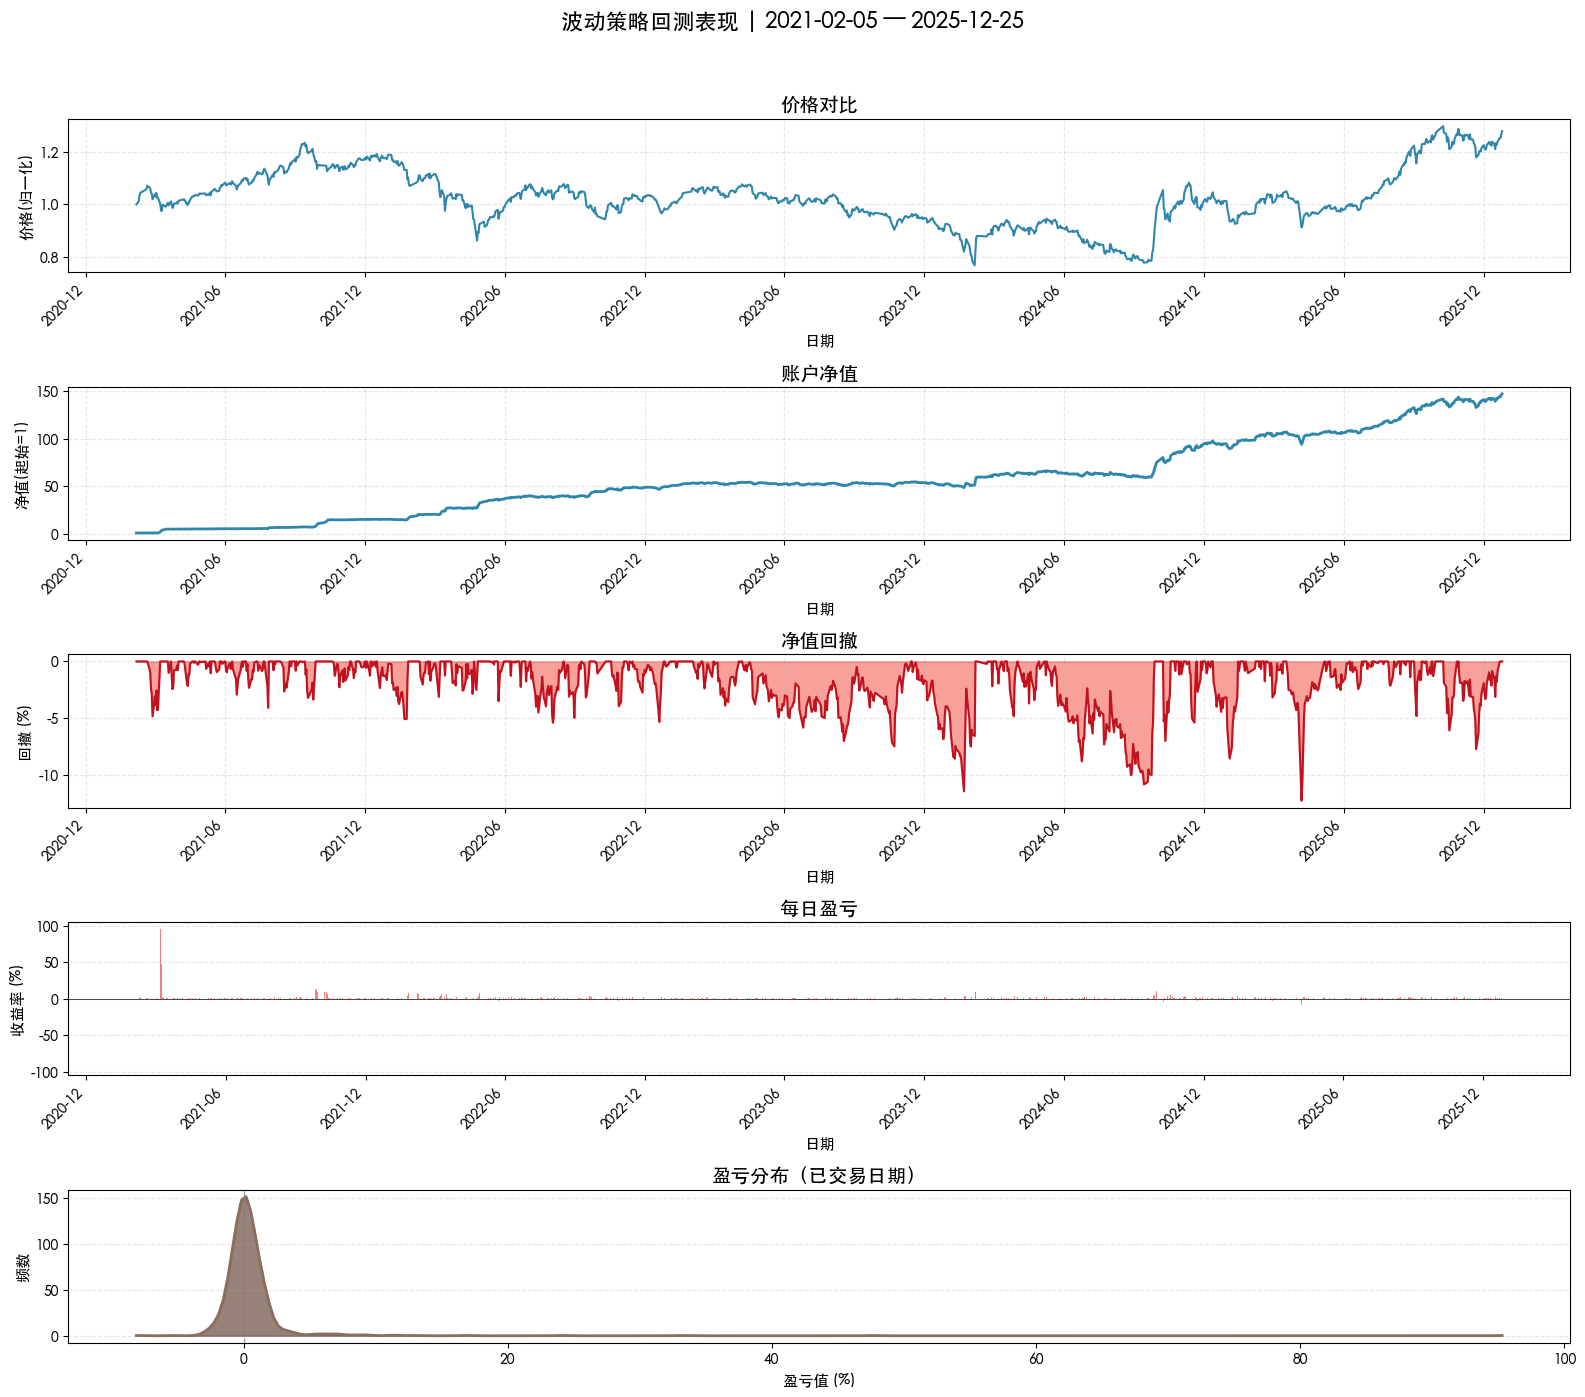

In [7]:
# 6. 可视化回测结果
from deltafq.charts import PerformanceChart

def plot_backtest_performance(values_df: pd.DataFrame, 
                              benchmark_close: pd.Series = None,
                              title: str = "波动策略回测表现",
                              use_plotly: bool = False):
    """使用PerformanceChart可视化回测结果"""
    # 确保 values_df 格式正确
    values_df = values_df.copy()
    
    # 从第一次有资产开始（避免初始为0导致的计算问题）
    first_valid_idx = values_df[values_df['total_value'] > 0].index
    if len(first_valid_idx) > 0:
        values_df = values_df.loc[first_valid_idx[0]:]
    
    # 清理无效值
    values_df['total_value'] = values_df['total_value'].replace([float('inf'), -float('inf')], 0)
    values_df['total_value'] = values_df['total_value'].fillna(0)
    values_df['price'] = values_df['price'].fillna(method='ffill').fillna(method='bfill')
    
    # 确保 total_value 至少有一个非零值
    if (values_df['total_value'] == 0).all():
        values_df.loc[values_df.index[0], 'total_value'] = 1.0
    
    # 对齐 benchmark_close 索引
    if benchmark_close is not None:
        benchmark_close = benchmark_close.reindex(values_df.index, method='ffill').fillna(method='bfill')
        # 清理 benchmark 的无效值
        benchmark_close = benchmark_close.replace([float('inf'), -float('inf')], 0)
        benchmark_close = benchmark_close.fillna(method='ffill').fillna(method='bfill')
    
    performance_chart = PerformanceChart()
    performance_chart.plot_backtest_charts(
        values_df=values_df,
        benchmark_close=benchmark_close,
        title=title,
        use_plotly=use_plotly
    )

plot_backtest_performance(values_df=values_df)


In [8]:
# 7. 策略参数对比：测试不同的窗口期和跌幅阈值组合
param_combinations = [
    {'window': 10, 'threshold': 0.05, 'name': '10日-5%'},
    {'window': 10, 'threshold': 0.10, 'name': '10日-10%'},
    {'window': 20, 'threshold': 0.05, 'name': '20日-5%'},
    {'window': 20, 'threshold': 0.10, 'name': '20日-10%'},
]

comparison_results = []

for params in param_combinations:
    strategy_test = VolatilityStrategy(
        window=params['window'], 
        threshold=params['threshold'], 
        name=f"VolatilityStrategy_{params['name']}"
    )
    result_test = strategy_test.run(data)
    signals_test = result_test["signals"]
    
    values_df_test, summary_test = backtest_volatility_strategy(
        data, signals_test, investment_amount=2000, commission=0
    )
    
    comparison_results.append({
        '策略参数': params['name'],
        '窗口期': f"{params['window']}日",
        '跌幅阈值': f"{params['threshold']*100:.0f}%",
        '加仓次数': (signals_test == 1).sum(),
        '累计投入': summary_test['累计投入'],
        '最终资产': summary_test['最终资产'],
        '累计收益率': summary_test['累计收益率'],
        '年化收益率': summary_test['年化收益率']
    })

comparison_df = pd.DataFrame(comparison_results)
print("\n不同参数组合对比:")
print(comparison_df.to_string(index=False))


[20:47:45] VolatilityStrategy_10日-5% >>> INFO     >>> Initializing strategy: VolatilityStrategy_10日-5%
[20:47:45] VolatilityStrategy_10日-5% >>> INFO     >>> Running strategy: VolatilityStrategy_10日-5%
[20:47:45] VolatilityStrategy_10日-10% >>> INFO     >>> Initializing strategy: VolatilityStrategy_10日-10%
[20:47:45] VolatilityStrategy_10日-10% >>> INFO     >>> Running strategy: VolatilityStrategy_10日-10%
[20:47:45] VolatilityStrategy_20日-5% >>> INFO     >>> Initializing strategy: VolatilityStrategy_20日-5%
[20:47:45] VolatilityStrategy_20日-5% >>> INFO     >>> Running strategy: VolatilityStrategy_20日-5%
[20:47:46] VolatilityStrategy_20日-10% >>> INFO     >>> Initializing strategy: VolatilityStrategy_20日-10%
[20:47:46] VolatilityStrategy_20日-10% >>> INFO     >>> Running strategy: VolatilityStrategy_20日-10%

不同参数组合对比:
   策略参数 窗口期 跌幅阈值  加仓次数       累计投入       最终资产  累计收益率 年化收益率
 10日-5% 10日   5%   112 224,000.00 293,920.65 31.21% 5.62%
10日-10% 10日  10%    12  24,000.00  34,020.91 41.75% 7.27%
 20